# 03_Model_experiments
## Выбор модели

##### Много импортов

In [17]:
import pandas as pd
import joblib
from sklearn.metrics import average_precision_score
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import precision_recall_curve, confusion_matrix, classification_report, accuracy_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

##### Загрузка обработанного датасета

In [2]:
df = pd.read_csv("../data/processed/smartphone_addiction_proc.csv")

### Разбиение данных на train, test.

In [3]:
X = df.drop("addiction", axis=1)
Y = df["addiction"]

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

### Базовая модель - самый частый класс

In [9]:
dummy = DummyClassifier(strategy='most_frequent')

In [10]:
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

pr_auc_dummy = average_precision_score(y_test, y_pred_dummy)
f1_score_dummy = f1_score(y_test, y_pred_dummy)
accuracy_dummy = accuracy_score(y_test, y_pred_dummy)

print("Most Frequent Class")
print(f"F1: {f1_score_dummy:.4f}")
print(f"PR-AUC: {pr_auc_dummy:.4f}")
print(f"Accuracy: {accuracy_dummy:.4f}")

Most Frequent Class
F1: 0.8290
PR-AUC: 0.7080
Accuracy: 0.7080


### Большое сравнение разных моделей с подбором лучших параметров через RandomSearch.
- Логистическая регрессия
-

In [9]:
# Подготовка для лог регрессии
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

СРАВНЕНИЕ МОДЕЛЕЙ (PR AUC)

1. LOGISTIC REGRESSION
Лучшие параметры: {'max_iter': 2000, 'class_weight': 'balanced', 'C': 10}
PR AUC: 0.9808

2. DECISION TREE
Лучшие параметры: {'min_samples_split': 20, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_depth': 3, 'criterion': 'gini', 'class_weight': None}
PR AUC: 0.9820

3. RANDOM FOREST
Лучшие параметры: {'n_estimators': 300, 'min_samples_split': 20, 'min_samples_leaf': 10, 'max_features': 'log2', 'max_depth': 10, 'class_weight': None}
PR AUC: 0.9960

4. GRADIENT BOOSTING
Лучшие параметры: {'subsample': 1.0, 'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_depth': 5, 'learning_rate': 0.1}
PR AUC: 0.9959

5. XGBOOST
Лучшие параметры: {'subsample': 0.8, 'reg_lambda': 10, 'reg_alpha': 0, 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.8}
PR AUC: 0.9958

6. LIGHTGBM
Лучшие параметры: {'subsample': 1.0, 'reg_lambda': 10, 'reg_alpha': 0, 'num_le

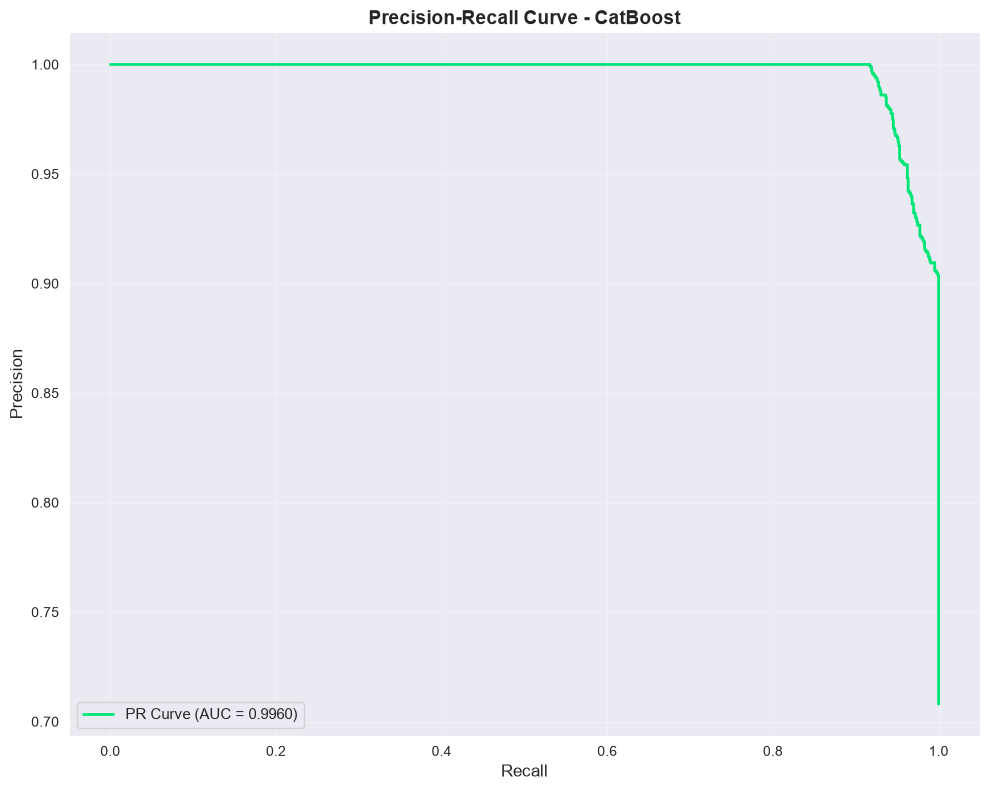


Confusion Matrix:


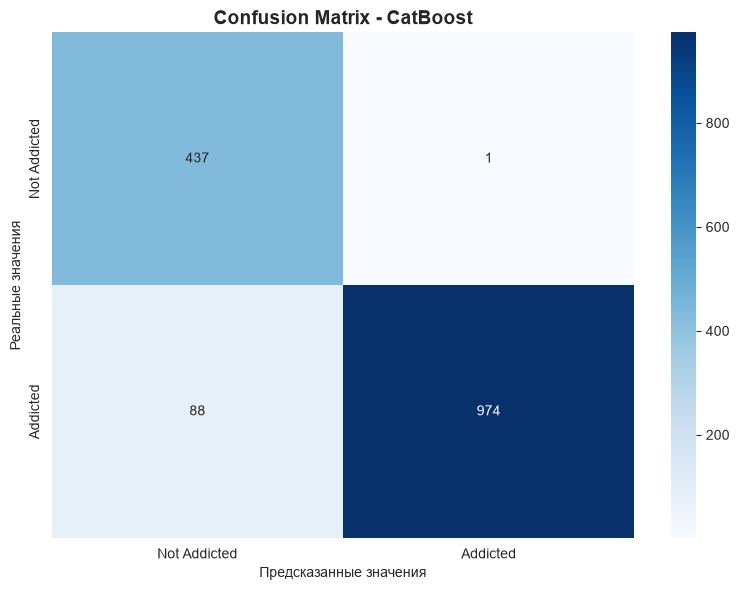


Classification Report:
              precision    recall  f1-score   support

Not Addicted       0.83      1.00      0.91       438
    Addicted       1.00      0.92      0.96      1062

    accuracy                           0.94      1500
   macro avg       0.92      0.96      0.93      1500
weighted avg       0.95      0.94      0.94      1500



In [35]:
results = []

print("СРАВНЕНИЕ МОДЕЛЕЙ ПО PR AUC")

def evaluate_model(name, model, X_test_data, y_test):
    """Оценка модели с PR AUC"""
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test_data)[:, 1]
    else:
        y_proba = model.predict(X_test_data)

    y_pred = model.predict(X_test_data)

    pr_auc = average_precision_score(y_test, y_proba)
    accuracy = accuracy_score(y_test, y_pred)

    return {
        'model': name,
        'pr_auc': pr_auc,
        'accuracy': accuracy,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'estimator': model
    }

# 1. LOGISTIC REGRESSION
print("1. LOGISTIC REGRESSION")

param_dist_lr = {
    'C': [0.01, 0.1, 1, 10],
    'max_iter': [1000, 2000],
    'class_weight': ['balanced', None]
}

lr = LogisticRegression(random_state=42)
random_search_lr = RandomizedSearchCV(lr, param_dist_lr, n_iter=10, cv=5,
                                      scoring='average_precision', n_jobs=-1, random_state=42)
random_search_lr.fit(X_train_scaled, y_train)

best_lr = random_search_lr.best_estimator_
result_lr = evaluate_model('Logistic Regression', best_lr, X_test_scaled, y_test)
results.append(result_lr)
print(f"Лучшие параметры: {random_search_lr.best_params_}")
print(f"PR AUC: {result_lr['pr_auc']:.4f}")

# 2. DECISION TREE
print("2. DECISION TREE")

param_dist_tree = {
    'max_depth': [2, 3, 5, 7, 10, 15],
    'min_samples_split': [10, 20, 50],
    'min_samples_leaf': [5, 10, 20],
    'max_features': ['sqrt', 'log2'],
    'criterion': ['gini', 'entropy'],
    'class_weight': ['balanced', None]
}

tree = DecisionTreeClassifier(random_state=42)
random_search_tree = RandomizedSearchCV(tree, param_dist_tree, n_iter=20, cv=5,
                                        scoring='average_precision', n_jobs=-1, random_state=42)
random_search_tree.fit(X_train, y_train)

best_tree = random_search_tree.best_estimator_
result_tree = evaluate_model('Decision Tree', best_tree, X_test, y_test)
results.append(result_tree)
print(f"Лучшие параметры: {random_search_tree.best_params_}")
print(f"PR AUC: {result_tree['pr_auc']:.4f}")

# 3. RANDOM FOREST
print("3. RANDOM FOREST")

param_dist_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 7, 10, 15],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [2, 5, 10],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced', 'balanced_subsample', None]
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)
random_search_rf = RandomizedSearchCV(rf, param_dist_rf, n_iter=20, cv=5,
                                      scoring='average_precision', n_jobs=-1, random_state=42)
random_search_rf.fit(X_train, y_train)

best_rf = random_search_rf.best_estimator_
result_rf = evaluate_model('Random Forest', best_rf, X_test, y_test)
results.append(result_rf)
print(f"Лучшие параметры: {random_search_rf.best_params_}")
print(f"PR AUC: {result_rf['pr_auc']:.4f}")

# 4. GRADIENT BOOSTING
print("4. GRADIENT BOOSTING")

param_dist_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 5],
    'subsample': [0.8, 1.0]
}

gb = GradientBoostingClassifier(random_state=42)
random_search_gb = RandomizedSearchCV(gb, param_dist_gb, n_iter=15, cv=5,
                                      scoring='average_precision', n_jobs=-1, random_state=42)
random_search_gb.fit(X_train, y_train)

best_gb = random_search_gb.best_estimator_
result_gb = evaluate_model('Gradient Boosting', best_gb, X_test, y_test)
results.append(result_gb)
print(f"Лучшие параметры: {random_search_gb.best_params_}")
print(f"PR AUC: {result_gb['pr_auc']:.4f}")

# 5. XGBOOST
print("5. XGBOOST")

param_dist_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.1],
    'reg_alpha': [0, 0.1],
    'reg_lambda': [1, 10]
}

xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
random_search_xgb = RandomizedSearchCV(xgb, param_dist_xgb, n_iter=20, cv=5,
                                       scoring='average_precision', n_jobs=-1, random_state=42)
random_search_xgb.fit(X_train, y_train)

best_xgb = random_search_xgb.best_estimator_
result_xgb = evaluate_model('XGBoost', best_xgb, X_test, y_test)
results.append(result_xgb)
print(f"Лучшие параметры: {random_search_xgb.best_params_}")
print(f"PR AUC: {result_xgb['pr_auc']:.4f}")

# 6. LIGHTGBM
print("6. LIGHTGBM")

param_dist_lgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [15, 31, 63],
    'max_depth': [5, 7, 10],
    'min_child_samples': [10, 20],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'reg_alpha': [0, 0.1],
    'reg_lambda': [1, 10]
}

lgb = LGBMClassifier(random_state=42, verbose=-1)
random_search_lgb = RandomizedSearchCV(lgb, param_dist_lgb, n_iter=20, cv=5,
                                       scoring='average_precision', n_jobs=-1, random_state=42)
random_search_lgb.fit(X_train, y_train)

best_lgb = random_search_lgb.best_estimator_
result_lgb = evaluate_model('LightGBM', best_lgb, X_test, y_test)
results.append(result_lgb)
print(f"Лучшие параметры: {random_search_lgb.best_params_}")
print(f"PR AUC: {result_lgb['pr_auc']:.4f}")

# 7. CATBOOST
print("7. CATBOOST")

param_dist_cat = {
    'iterations': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'depth': [3, 5, 7],
    'l2_leaf_reg': [1, 5, 10],
    'auto_class_weights': ['Balanced', None]
}

cat = CatBoostClassifier(random_seed=42, verbose=False)
random_search_cat = RandomizedSearchCV(cat, param_dist_cat, n_iter=15, cv=5,
                                       scoring='average_precision', n_jobs=-1, random_state=42)
random_search_cat.fit(X_train, y_train)

best_cat = random_search_cat.best_estimator_
result_cat = evaluate_model('CatBoost', best_cat, X_test, y_test)
results.append(result_cat)
print(f"Лучшие параметры: {random_search_cat.best_params_}")
print(f"PR AUC: {result_cat['pr_auc']:.4f}")

# 8. VOTING CLASSIFIER
print("8. VOTING CLASSIFIER")

voting = VotingClassifier([
    ('rf', best_rf),
    ('xgb', best_xgb),
    ('lgb', best_lgb),
    ('cat', best_cat),
    ('gb', best_gb)
], voting='soft')

voting.fit(X_train, y_train)
result_voting = evaluate_model('Voting Classifier', voting, X_test, y_test)
results.append(result_voting)
print(f"Voting PR AUC: {result_voting['pr_auc']:.4f}")

# 9. STACKING CLASSIFIER
print("9. STACKING CLASSIFIER")

stacking = StackingClassifier([
    ('rf', best_rf),
    ('xgb', best_xgb),
    ('lgb', best_lgb),
    ('cat', best_cat)
], final_estimator=LogisticRegression(C=1, max_iter=1000))

stacking.fit(X_train, y_train)
result_stacking = evaluate_model('Stacking Classifier', stacking, X_test, y_test)
results.append(result_stacking)
print(f"Stacking PR AUC: {result_stacking['pr_auc']:.4f}")

# ИТОГОВОЕ СРАВНЕНИЕ
print("ИТОГОВОЕ СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ (PR AUC)")

df_results = pd.DataFrame([{k: v for k, v in r.items() if k not in ['y_pred', 'y_proba', 'estimator']}
                           for r in results]).sort_values('pr_auc', ascending=False)

print(df_results[['model', 'pr_auc', 'accuracy']].to_string(index=False))

best_model_name = df_results.iloc[0]['model']
best_result = [r for r in results if r['model'] == best_model_name][0]

print(f"ЛУЧШАЯ МОДЕЛЬ: {best_model_name}")
print(f"   PR AUC: {best_result['pr_auc']:.4f}")
print(f"   Accuracy: {best_result['accuracy']:.4f}")

### PR Curve для лучшей модели

In [ ]:
precision, recall, thresholds = precision_recall_curve(y_test, best_result['y_proba'])

plt.plot(recall, precision, color='#00E676', linewidth=2,
         label=f'PR Curve (AUC = {best_result["pr_auc"]:.4f})')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title(f'Precision-Recall Curve - {best_model_name}', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

### Confusion Matrix

In [ ]:
cm = confusion_matrix(y_test, best_result['y_pred'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Addicted', 'Addicted'],
            yticklabels=['Not Addicted', 'Addicted'])
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
plt.ylabel('Реальные значения')
plt.xlabel('Предсказанные значения')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, best_result['y_pred'],
                            target_names=['Not Addicted', 'Addicted']))

### Выбор модели
Я решил взять decision tree как итоговую модель, потому что дерево хорошо интерпретируется в отличие от остальных моделей с высшими результатами. Сами результаты дерева практически ничем не отличаются.

In [5]:
model = DecisionTreeClassifier(
    min_samples_split=20,
    min_samples_leaf=10,
    max_features='sqrt',
    max_depth=3,
    criterion='gini',
    class_weight=None
)

In [6]:
model.fit(X_train, y_train)
y_pred_tree = model.predict(X_test)

### Сравнение с dummy classifier

In [12]:
pr_auc_tree = average_precision_score(y_test, y_pred_tree)
f1_score_tree = f1_score(y_test, y_pred_tree)
accuracy_tree = accuracy_score(y_test, y_pred_tree)

print("Дерево решений:")
print(f"F1: {f1_score_tree:.4f}")
print(f"PR-AUC: {pr_auc_tree:.4f}")
print(f"Accuracy: {accuracy_tree:.4f}")

Дерево решений:
F1: 0.8488
PR-AUC: 0.9204
Accuracy: 0.8133


In [15]:
difference_pr_auc = pr_auc_tree - pr_auc_dummy
difference_f1 = f1_score_tree - f1_score_dummy
difference_accuracy = accuracy_tree - accuracy_dummy

print("Прирост модели:")
print(f"PR-AUC: {abs(difference_pr_auc):.2f}")
print(f"F1: {abs(difference_f1):.2f}")
print(f"Accuracy: {abs(difference_accuracy):.2f}")

Прирост модели:
PR-AUC: 0.21
F1: 0.02
Accuracy: 0.11


### Обучение на всем наборе данных

In [16]:
model = DecisionTreeClassifier(
    min_samples_split=20,
    min_samples_leaf=10,
    max_features='sqrt',
    max_depth=3,
    criterion='gini',
    class_weight=None
)

model.fit(X, Y)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",'sqrt'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsampl

In [18]:
joblib.dump(model, "../models/tree/decision_tree_v1.pkl")

['../models/tree/decision_tree_v1.pkl']